## Stock Price Predicition using Sentiment Analysis

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import plotly.graph_objects as go

In [142]:
#!pip install plotly

In [143]:
# !pip install yfinance

## Stock Example

In [144]:
tsla = yf.Ticker("TSLA")

In [145]:
hist = tsla.history(period="max")

<Axes: xlabel='Date'>

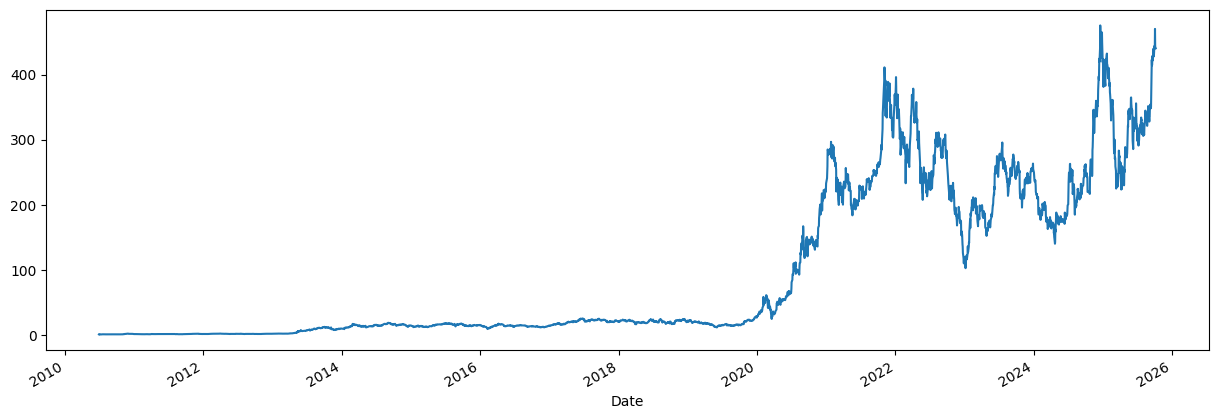

In [146]:
hist['Open'].plot(figsize=(15, 5))

## Pull a bunch of stocks

In [147]:
stocks = ['NVDA', 'MSFT', 'AAPL', 'GOOG', 'AMZN', 'META', 'AVGO', 'TSLA', 'BRK-B', 'JPM']

In [148]:
hists = {}
for s in stocks:
    tkr = yf.Ticker(s)
    history = tkr.history(period="6y")
    hists[s] = history

# Plot the stock price 

In [149]:
temp_df = hists["AAPL"].copy()

In [150]:
temp_df.index

DatetimeIndex(['2019-10-07 00:00:00-04:00', '2019-10-08 00:00:00-04:00',
               '2019-10-09 00:00:00-04:00', '2019-10-10 00:00:00-04:00',
               '2019-10-11 00:00:00-04:00', '2019-10-14 00:00:00-04:00',
               '2019-10-15 00:00:00-04:00', '2019-10-16 00:00:00-04:00',
               '2019-10-17 00:00:00-04:00', '2019-10-18 00:00:00-04:00',
               ...
               '2025-09-23 00:00:00-04:00', '2025-09-24 00:00:00-04:00',
               '2025-09-25 00:00:00-04:00', '2025-09-26 00:00:00-04:00',
               '2025-09-29 00:00:00-04:00', '2025-09-30 00:00:00-04:00',
               '2025-10-01 00:00:00-04:00', '2025-10-02 00:00:00-04:00',
               '2025-10-03 00:00:00-04:00', '2025-10-06 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=1508, freq=None)

In [151]:
for stock in stocks:
    temp_df = hists[stock].copy()

    fig = go.Figure(data=[go.Candlestick(x=temp_df.index,
                    open=temp_df['Open'],
                    high=temp_df['High'],
                    low=temp_df['Low'],
                    close=temp_df['Close'])])

    fig.update_layout(
        margin = dict(l=20, r=20, t=60, b=20),
        height = 300,
        paper_bgcolor = "LightSteelBlue",
        title=stock,
    )


    fig.show()

# Pull Tweets about each Stock

In [152]:
#!pip install snscrape

In [153]:
stock = "AMZN"

In [ ]:
# !python -m pip install -U snscrape certifi
# if conda:
# conda update -y openssl ca-certificates certifi



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# importing libraries and packages
import snscrape.modules.twitter as sntwitter
from tqdm.notebook import tqdm

# Creating list to append tweet data
tweets_list = []

year = 2020

for i, tweet in tqdm(
    enumerate(
        sntwitter.TwitterSearchScraper(
            f"${stock} since:{year}-01-01 until:{year+5}-01-01"
        ).get_items()
    ),
    total=1000,
):  # declare a username
    if i > 1000:  # number of tweets you want to scrape
        break
    tweets_list.append(
        [tweet.date, tweet.id, tweet.content, tweet.user.username]
    )  # declare the attributes to be returned
# Creating a dataframe from the tweets list above
tweet_df = pd.DataFrame(
    tweets_list, columns=["Datetime", "Tweet Id", "Text", "Username"]
)
print(tweet_df.head())

NameError: name 'stock' is not defined